#**Maestría en Inteligencia Artificial Aplicada**
## TC5035.10
##**Curso: Proyecto Integrador**
###Tecnológico de Monterrey

---

**Docente Titular**: Dra. Grettel Barceló Alonso y Dr. Luis Eduardo Falcón

**Docente Asistente**: Veronica Guzman del Valle

**Docente Tutor**: Eduviges Ludivina Facundo Flores

**Docente del ITCJ Responsable**: Mtra. Yadira Dozal Assmar

#**Nombre del Proyecto:**
---
*"Modelado de serie de tiempo para pronosticar la demanda de prórrogas de licenciatura en ITCJ"*

---

#**Integrantes Equipo #13:**
* A01796362 Eduardo Perez Carrillo
* A01795907 Nancy Teresa Zapien García
* A01796060 Hugo Alberto Cuevas García

# **Avance 4 - MODELOS ALTERNATIVOS** (Reglas vs ML) **mensual con ceros** (2019–2025) + Pronóstico 2026–2027

Este notebook replica el flujo del baseline anterior, pero ahora convierte la serie semestral a **mensual** generando una malla completa de meses.

Como el origen solo tiene datos “reales” en **enero** y **julio** de cada año (S1/S2), los demás meses se rellenan con **0** para evaluar el efecto de tener más puntos en la serie.

**ML (supervisado):** usa como feature `total_solicitudes(t)` para predecir `total_solicitudes(t+1)` (one-step ahead).  
**Reglas:** se evalúan también one-step ahead.  
Al final se muestra pronóstico recursivo para **2026 y 2027** (mensual).


## 1) Carga (semestral) → Conversión a mensual

- Se carga el CSV semestral (2019–2025).
- Se crea un rango mensual completo.
- Se conservan los valores reales de enero/julio y el resto de meses se asigna 0.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import os
#from google.colab import drive

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# -----------------------
# Config
# -----------------------
DATA_PATH = "ts_dataset_2019_2025_sin_lags_sin_pca.csv"  # CSV semestral
TARGET = "total_solicitudes"

# -----------------------
# Load semestral
# -----------------------
df_s = pd.read_csv(DATA_PATH)
df_s["fecha"] = pd.to_datetime(df_s["fecha"])
df_s = df_s.sort_values("fecha").reset_index(drop=True)

print("Semestral | Rango:", df_s["fecha"].min().date(), "->", df_s["fecha"].max().date(), " | N:", len(df_s))
display(df_s)

# -----------------------
# Convert to monthly grid
# -----------------------
start = df_s["fecha"].min().replace(day=1)
end = df_s["fecha"].max().replace(day=1)

monthly_dates = pd.date_range(start=start, end=end, freq="MS")  # Month Start
df_m = pd.DataFrame({"fecha": monthly_dates})

# Map semestral points onto monthly grid (enero/julio)
df_s_map = df_s[["fecha", TARGET]].copy()
df_m = df_m.merge(df_s_map, on="fecha", how="left")

# Fill missing months with 0 as requested
df_m[TARGET] = df_m[TARGET].fillna(0).astype(float)

# Add helpers
df_m["anio"] = df_m["fecha"].dt.year
df_m["mes"] = df_m["fecha"].dt.month
df_m["mes_nombre"] = df_m["fecha"].dt.strftime("%Y-%m")

print("Mensual | Rango:", df_m["fecha"].min().date(), "->", df_m["fecha"].max().date(), " | N:", len(df_m))
display(df_m.head(15))

# Serie target mensual
series_y = df_m[TARGET].astype(float).reset_index(drop=True)

# -----------------------
# Supervised one-step ahead (mensual)
# X(t) -> y(t+1)
# -----------------------
df_sup = df_m.copy()
df_sup["y_next"] = df_sup[TARGET].shift(-1)
df_sup = df_sup.iloc[:-1].reset_index(drop=True)

# Feature set solicitado: SOLO total_solicitudes(t)
X = df_sup[[TARGET]].astype(float).copy()
y = df_sup["y_next"].astype(float).copy()

mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

print("Supervised N:", len(X), " | Features:", list(X.columns))



Semestral | Rango: 2019-01-01 -> 2025-07-01  | N: 14


,fecha,anio,semestre,total_solicitudes,aprobadas,no_aprobadas,promedio_semestre_alumno,promedio_duracion_prorroga,total_semestres_otorgados
0,2019-01-01,2019,S1,0,0,0,NaN,NaN,0
1,2019-07-01,2019,S2,39,39,0,6.512821,7.461538,291
2,2020-01-01,2020,S1,0,0,0,NaN,NaN,0
3,2020-07-01,2020,S2,175,160,15,6.708571,6.834286,1196
4,2021-01-01,2021,S1,254,251,3,6.586614,6.259843,1590
5,2021-07-01,2021,S2,49,34,15,6.693878,5.102041,250
6,2022-01-01,2022,S1,30,17,13,6.866667,4.466667,134
7,2022-07-01,2022,S2,212,196,16,6.556604,6.523585,1383
8,2023-01-01,2023,S1,121,95,26,6.016529,5.487603,664
9,2023-07-01,2023,S2,258,255,3,6.550388,7.108527,1834


Mensual | Rango: 2019-01-01 -> 2025-07-01  | N: 79


,fecha,total_solicitudes,anio,mes,mes_nombre
0,2019-01-01,0.0,2019,1,2019-01
1,2019-02-01,0.0,2019,2,2019-02
2,2019-03-01,0.0,2019,3,2019-03
3,2019-04-01,0.0,2019,4,2019-04
4,2019-05-01,0.0,2019,5,2019-05
5,2019-06-01,0.0,2019,6,2019-06
6,2019-07-01,39.0,2019,7,2019-07
7,2019-08-01,0.0,2019,8,2019-08
8,2019-09-01,0.0,2019,9,2019-09
9,2019-10-01,0.0,2019,10,2019-10


Supervised N: 78  | Features: ['total_solicitudes']


## 2) Split temporal: Train vs Holdout (mensual)

Se reserva un holdout final (por defecto 6 meses; si hay pocos puntos, baja a 3 o 1).


In [ ]:

# -----------------------
# Holdout temporal
# -----------------------
if len(X) >= 24:
    HOLDOUT = 6
elif len(X) >= 12:
    HOLDOUT = 3
else:
    HOLDOUT = 1

train_end = len(X) - HOLDOUT

X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]

print("Train:", len(X_train), " | Holdout:", len(X_test))

test_t_idx = np.arange(train_end, len(X))
test_y_true = series_y.iloc[test_t_idx + 1].reset_index(drop=True)
test_dates = df_m["fecha"].iloc[test_t_idx + 1].reset_index(drop=True)

display(pd.DataFrame({"fecha": test_dates, "y_true": test_y_true}).head(12))


Train: 72  | Holdout: 6


,fecha,y_true
0,2025-02-01,0.0
1,2025-03-01,0.0
2,2025-04-01,0.0
3,2025-05-01,0.0
4,2025-06-01,0.0
5,2025-07-01,327.0


## 3) Métricas

In [ ]:

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps) / 2.0
    return float(np.mean(np.abs(y_pred - y_true) / denom) * 100.0)


## 4) Baseline 1 (Reglas de forecasting) — mensual

Reglas evaluadas (one-step ahead):
- Naive
- Seasonal Naive (periodo = 12 por meses)
- Moving Average (k=2)
- Drift
- Simple Exponential Smoothing (SES) / Holt fallback


In [ ]:

def baseline1_predict(rule_name: str, series: pd.Series, idx_start: int, idx_end: int, seasonal_periods=12):
    '''
    Predicción one-step ahead para series[t] usando historial series[:t].
    '''
    preds = []
    for t in range(idx_start, idx_end + 1):
        hist = series.iloc[:t].astype(float)

        if rule_name == "Naive":
            yhat = hist.iloc[-1]

        elif rule_name == "SeasonalNaive":
            if t - seasonal_periods < 0:
                yhat = hist.iloc[-1]
            else:
                yhat = series.iloc[t - seasonal_periods]

        elif rule_name == "MovingAvg2":
            k = 2
            if len(hist) < k:
                yhat = hist.iloc[-1]
            else:
                yhat = hist.iloc[-k:].mean()

        elif rule_name == "Drift":
            if len(hist) < 2:
                yhat = hist.iloc[-1]
            else:
                yhat = hist.iloc[-1] + (hist.iloc[-1] - hist.iloc[0]) / (len(hist) - 1)

        elif rule_name == "ExpSmoothing":
            if len(hist) < 3:
                yhat = hist.iloc[-1]
            else:
                try:
                    model = SimpleExpSmoothing(hist, initialization_method="estimated")
                    fit = model.fit(optimized=True)
                    yhat = float(fit.forecast(1).iloc[0])
                except Exception:
                    try:
                        model = ExponentialSmoothing(hist, trend="add", initialization_method="estimated")
                        fit = model.fit(optimized=True)
                        yhat = float(fit.forecast(1).iloc[0])
                    except Exception:
                        yhat = hist.iloc[-1]
        else:
            raise ValueError("Regla no reconocida")

        preds.append(float(yhat))
    return np.array(preds, dtype=float)

baseline1_rules = ["Naive", "SeasonalNaive", "MovingAvg2", "Drift", "ExpSmoothing"]


## 5) Baseline 2 (ML supervisado) — mensual

Modelos comparados:
- LinearRegression
- Ridge
- Lasso
- DecisionTree
- GradientBoosting

Feature: `total_solicitudes(t)`


In [ ]:

ml_models = {
    "LinearRegression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0, random_state=42))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.01, random_state=42, max_iter=10000))]),
    "DecisionTree": DecisionTreeRegressor(max_depth=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}


## 6) Evaluación con CV temporal + Holdout (mensual)

In [ ]:

def evaluate_ml_cv(model, X, y, n_splits=5):
    max_splits = max(2, min(n_splits, len(X) - 2))
    tscv = TimeSeriesSplit(n_splits=max_splits)
    maes, rmses, smapes = [], [], []
    for tr, te in tscv.split(X):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        maes.append(mean_absolute_error(y_te, pred))
        rmses.append(rmse(y_te, pred))
        smapes.append(smape(y_te, pred))
    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(smapes))

def evaluate_baseline1_cv(rule_name, series, X_len, n_splits=5):
    max_splits = max(2, min(n_splits, X_len - 2))
    tscv = TimeSeriesSplit(n_splits=max_splits)
    maes, rmses, smapes = [], [], []
    for _, te in tscv.split(np.arange(X_len)):
        preds, trues = [], []
        for t in te:
            target_index = t + 1
            pred = baseline1_predict(rule_name, series, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0]
            preds.append(pred)
            trues.append(float(series.iloc[target_index]))
        maes.append(mean_absolute_error(trues, preds))
        rmses.append(rmse(trues, preds))
        smapes.append(smape(trues, preds))
    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(smapes))

results = []

# Baseline 1
for rule in baseline1_rules:
    cv_mae, cv_rmse, cv_smape = evaluate_baseline1_cv(rule, series_y, X_len=len(X), n_splits=5)

    preds_hold = []
    for t in test_t_idx:
        target_index = t + 1
        preds_hold.append(baseline1_predict(rule, series_y, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0])
    preds_hold = np.array(preds_hold, dtype=float)

    results.append({
        "Family": "Rules",
        "Model": rule,
        "MAE_CV": cv_mae,
        "RMSE_CV": cv_rmse,
        "sMAPE_CV": cv_smape,
        "MAE_Holdout": mean_absolute_error(test_y_true, preds_hold),
        "RMSE_Holdout": rmse(test_y_true, preds_hold),
        "sMAPE_Holdout": smape(test_y_true, preds_hold),
    })

# Baseline 2
for name, model in ml_models.items():
    cv_mae, cv_rmse, cv_smape = evaluate_ml_cv(model, X, y, n_splits=5)

    model.fit(X_train, y_train)
    preds_hold = model.predict(X_test)

    results.append({
        "Family": "ML",
        "Model": name,
        "MAE_CV": cv_mae,
        "RMSE_CV": cv_rmse,
        "sMAPE_CV": cv_smape,
        "MAE_Holdout": mean_absolute_error(test_y_true, preds_hold),
        "RMSE_Holdout": rmse(test_y_true, preds_hold),
        "sMAPE_Holdout": smape(test_y_true, preds_hold),
    })

results_df = pd.DataFrame(results).sort_values(["MAE_Holdout", "MAE_CV"]).reset_index(drop=True)
display(results_df)


,Family,Model,MAE_CV,RMSE_CV,sMAPE_CV,MAE_Holdout,RMSE_Holdout,sMAPE_Holdout
0,Rules,SeasonalNaive,18.276923,49.130249,14.202793,17.000000,41.641326,6.159420
1,ML,DecisionTree,37.549647,69.642841,160.494588,67.604839,124.647909,161.719713
2,ML,GradientBoosting,37.549678,69.642844,191.263709,67.604890,124.647934,195.053008
3,ML,LinearRegression,38.639673,69.960263,191.526771,68.452019,124.951440,195.225287
4,ML,Lasso,38.631058,69.959507,191.527984,68.453432,124.952561,195.225890
5,ML,Ridge,38.576055,69.953942,191.542868,68.467009,124.963357,195.231684
6,Rules,ExpSmoothing,41.462439,69.986851,191.946528,71.255499,126.066455,195.571969
7,Rules,Naive,53.830769,97.851057,64.615385,76.833333,144.271157,66.666667
8,Rules,MovingAvg2,53.830769,86.415314,95.384615,76.833333,138.988609,100.000000
9,Rules,Drift,54.484954,99.031002,64.615385,77.143519,144.560968,66.666667


## 7) Gráfica: Real vs Predicción (Holdout) — mensual

Best Rules: SeasonalNaive
Best ML: DecisionTree


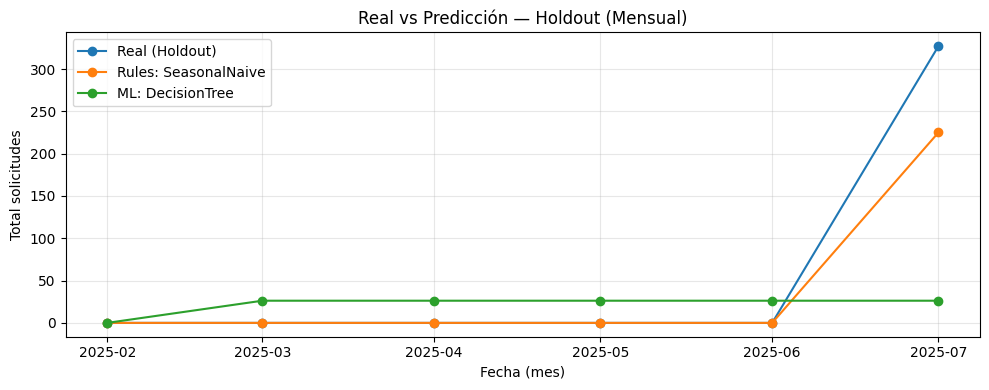

In [ ]:

best_rules = results_df[results_df["Family"]=="Rules"].iloc[0]["Model"]
best_ml = results_df[results_df["Family"]=="ML"].iloc[0]["Model"]

print("Best Rules:", best_rules)
print("Best ML:", best_ml)

pred_rules = []
for t in test_t_idx:
    target_index = t + 1
    pred_rules.append(baseline1_predict(best_rules, series_y, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0])
pred_rules = np.array(pred_rules, dtype=float)

ml = ml_models[best_ml]
ml.fit(X_train, y_train)
pred_ml = ml.predict(X_test)

plt.figure(figsize=(10,4))
plt.plot(test_dates, test_y_true, marker="o", label="Real (Holdout)")
plt.plot(test_dates, pred_rules, marker="o", label=f"Rules: {best_rules}")
plt.plot(test_dates, pred_ml, marker="o", label=f"ML: {best_ml}")
plt.title("Real vs Predicción — Holdout (Mensual)")
plt.xlabel("Fecha (mes)")
plt.ylabel("Total solicitudes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 8) Pronóstico 2026–2027 (mensual, 24 meses)

Se pronostican 24 meses:
- 2026-01 a 2027-12

**Reglas:** se aplican sobre la serie extendida.  
**ML:** pronóstico recursivo usando como feature el último valor (real o predicho).


,fecha,periodo,forecast_rules_SeasonalNaive,forecast_ml_DecisionTree
0,2025-08-01,2025-08,0.0,0.000000
1,2025-09-01,2025-09,0.0,29.134328
2,2025-10-01,2025-10,0.0,0.000000
3,2025-11-01,2025-11,0.0,29.134328
4,2025-12-01,2025-12,0.0,0.000000
5,2026-01-01,2026-01,134.0,29.134328
6,2026-02-01,2026-02,0.0,0.000000
7,2026-03-01,2026-03,0.0,29.134328
8,2026-04-01,2026-04,0.0,0.000000
9,2026-05-01,2026-05,0.0,29.134328


,fecha,periodo,forecast_rules_SeasonalNaive,forecast_ml_DecisionTree
12,2026-08-01,2026-08,0.0,0.000000
13,2026-09-01,2026-09,0.0,29.134328
14,2026-10-01,2026-10,0.0,0.000000
15,2026-11-01,2026-11,0.0,29.134328
16,2026-12-01,2026-12,0.0,0.000000
17,2027-01-01,2027-01,134.0,29.134328
18,2027-02-01,2027-02,0.0,0.000000
19,2027-03-01,2027-03,0.0,29.134328
20,2027-04-01,2027-04,0.0,0.000000
21,2027-05-01,2027-05,0.0,29.134328


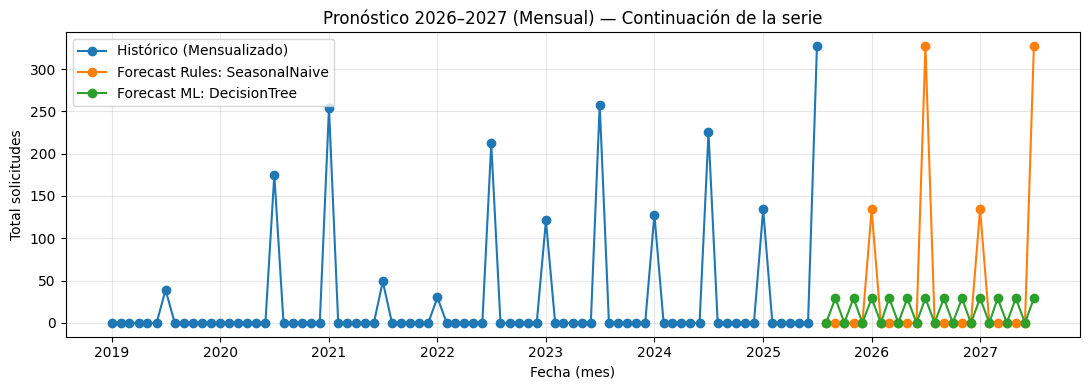

In [ ]:

def make_future_months(last_date, steps=24):
    last = pd.Timestamp(last_date).replace(day=1)
    return list(pd.date_range(last + pd.offsets.MonthBegin(1), periods=steps, freq="MS"))

future_dates = make_future_months(df_m["fecha"].iloc[-1], steps=24)
future_labels = [d.strftime("%Y-%m") for d in future_dates]

# Forecast Rules
series_ext = series_y.copy()
preds_rules_future = []
for _ in range(24):
    target_index = len(series_ext)
    pred = baseline1_predict(best_rules, series_ext, idx_start=target_index, idx_end=target_index, seasonal_periods=12)[0]
    preds_rules_future.append(float(pred))
    series_ext = pd.concat([series_ext, pd.Series([pred])], ignore_index=True)

# Forecast ML
ml = ml_models[best_ml]
ml.fit(X, y)  # entrenar con todo 2019–2025 mensualizado
last_val = float(series_y.iloc[-1])
preds_ml_future = []
for _ in range(24):
    x_in = pd.DataFrame({TARGET: [last_val]})
    yhat = float(ml.predict(x_in)[0])
    preds_ml_future.append(yhat)
    last_val = yhat

forecast_df = pd.DataFrame({
    "fecha": future_dates,
    "periodo": future_labels,
    f"forecast_rules_{best_rules}": preds_rules_future,
    f"forecast_ml_{best_ml}": preds_ml_future,
})
display(forecast_df.head(12))
display(forecast_df.tail(12))

plt.figure(figsize=(11,4))
plt.plot(df_m["fecha"], series_y, marker="o", label="Histórico (Mensualizado)")
plt.plot(forecast_df["fecha"], forecast_df[f"forecast_rules_{best_rules}"], marker="o", label=f"Forecast Rules: {best_rules}")
plt.plot(forecast_df["fecha"], forecast_df[f"forecast_ml_{best_ml}"], marker="o", label=f"Forecast ML: {best_ml}")
plt.title("Pronóstico 2026–2027 (Mensual) — Continuación de la serie")
plt.xlabel("Fecha (mes)")
plt.ylabel("Total solicitudes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


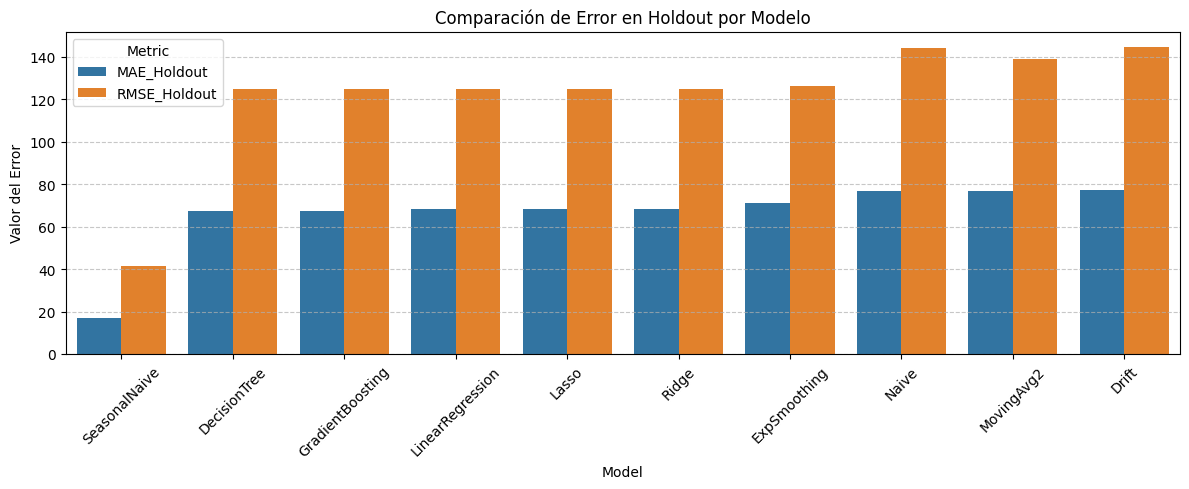

In [ ]:
import seaborn as sns

# Convertimos a formato largo para graficar fácilmente con seaborn
results_melted = results_df.melt(id_vars=["Model", "Family"], value_vars=["MAE_Holdout", "RMSE_Holdout"],
                                 var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x="Model", y="Value", hue="Metric")
plt.title("Comparación de Error en Holdout por Modelo")
plt.xticks(rotation=45)
plt.ylabel("Valor del Error")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\52656\AppData\Local\Temp\ipykernel_12292\3638580810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m, x="mes", y=TARGET, palette="viridis")


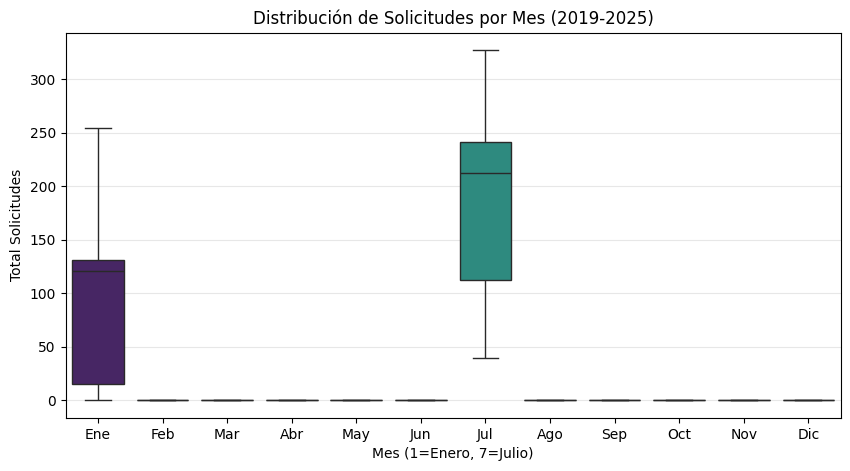

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_m, x="mes", y=TARGET, palette="viridis")
plt.title("Distribución de Solicitudes por Mes (2019-2025)")
plt.xlabel("Mes (1=Enero, 7=Julio)")
plt.ylabel("Total Solicitudes")
# Etiquetas para los meses
plt.xticks(ticks=range(12), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.grid(axis='y', alpha=0.3)
plt.show()

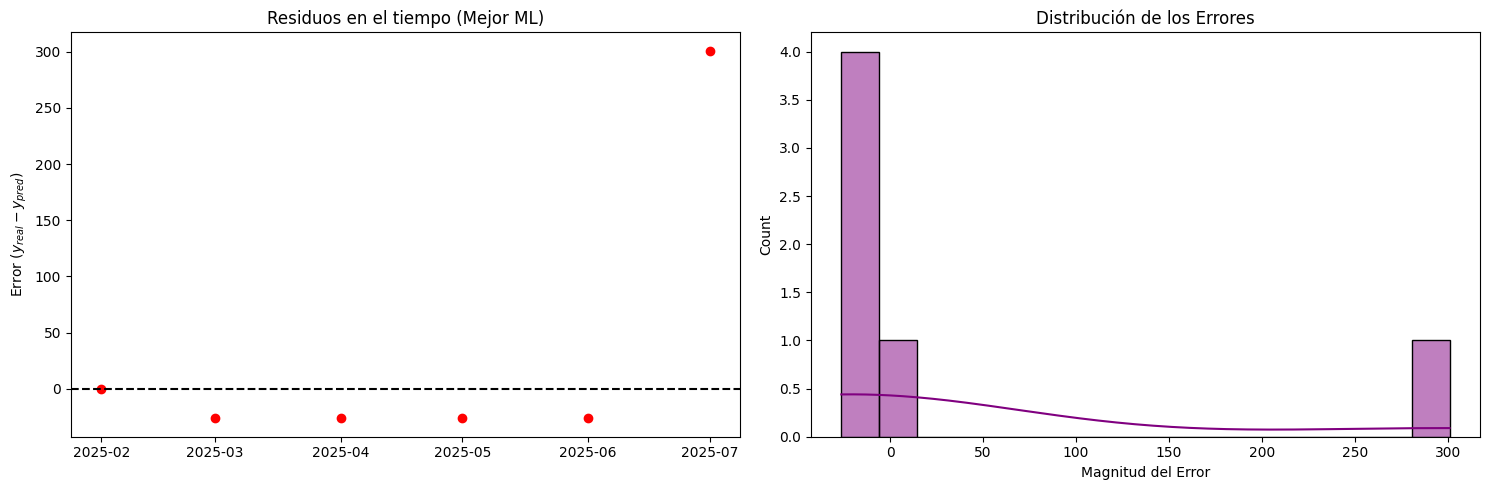

In [ ]:
# Suponiendo que 'pred_ml' son las predicciones del mejor modelo ML en el holdout
residuos = test_y_true - pred_ml

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Residuos a lo largo del tiempo
ax[0].scatter(test_dates, residuos, color='red')
ax[0].axhline(y=0, color='black', linestyle='--')
ax[0].set_title("Residuos en el tiempo (Mejor ML)")
ax[0].set_ylabel("Error ($y_{real} - y_{pred}$)")

# Distribución de los residuos
sns.histplot(residuos, kde=True, ax=ax[1], color='purple')
ax[1].set_title("Distribución de los Errores")
ax[1].set_xlabel("Magnitud del Error")

plt.tight_layout()
plt.show()

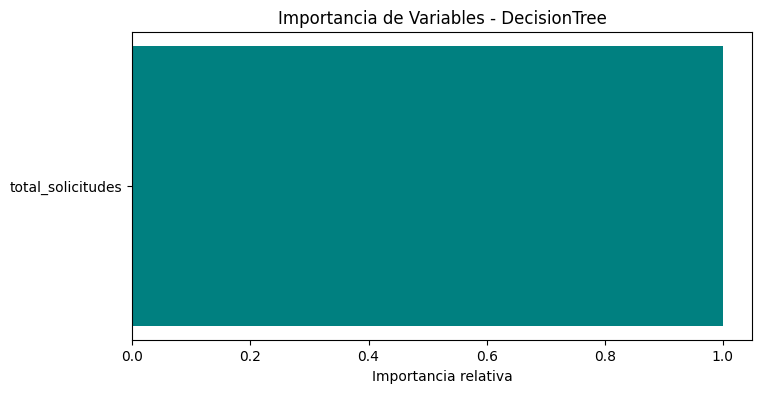

In [ ]:

# Si 'ml' es un DecisionTreeRegressor:
importances = ml.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
plt.barh(features, importances, color='teal')
plt.title(f"Importancia de Variables - {best_ml}")
plt.xlabel("Importancia relativa")
plt.show()

----
#**Ajuste de hiperparámetros de los modelos seleccionados**

#**Modelo Decision Tree**

El modelo Decision Tree puede mejorar su capacidad de generalización ajustando la profundidad del árbol y el número mínimo de muestras por nodo.

#**Modelo Gradient Boosting**

Gradient Boosting suele mejorar mucho con tuning porque controla cómo se construyen los árboles secuenciales.

In [ ]:
# ==========================================================
# Hiperparam tuning (DecisionTree & GradientBoosting)
#   - Tabla comparativa: ORIGINAL vs variantes
#   - Reutiliza variables del notebook: X_train, y_train, X_test, y_test,
#     test_y_true, rmse(), smape()
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from itertools import product

# -----------------------------
# Helpers
# -----------------------------
def _safe_smape(y_true, y_pred):
    # Usa tu función smape si existe; si no, cae a una implementación robusta
    try:
        return smape(y_true, y_pred)
    except NameError:
        y_true = np.array(y_true, dtype=float)
        y_pred = np.array(y_pred, dtype=float)
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
        denom = np.where(denom == 0, 1e-9, denom)
        return np.mean(np.abs(y_true - y_pred) / denom) * 100.0

def _safe_rmse(y_true, y_pred):
    # Usa tu función rmse si existe; si no, cae a una implementación robusta
    try:
        return rmse(y_true, y_pred)
    except NameError:
        y_true = np.array(y_true, dtype=float)
        y_pred = np.array(y_pred, dtype=float)
        return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true):
    """Entrena en train y evalúa en holdout (alineado a y(t+1))."""
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    return {
        "MAE_Holdout": float(mean_absolute_error(test_y_true, yhat)),
        "RMSE_Holdout": float(_safe_rmse(test_y_true, yhat)),
        "sMAPE_Holdout": float(_safe_smape(test_y_true, yhat)),
    }

def evaluate_model_cv(model, X, y, n_splits=5):
    """CV temporal con TimeSeriesSplit."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    maes, rmses, smapes = [], [], []
    for tr_idx, va_idx in tscv.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        model.fit(X_tr, y_tr)
        yhat = model.predict(X_va)

        maes.append(mean_absolute_error(y_va, yhat))
        rmses.append(_safe_rmse(y_va, yhat))
        smapes.append(_safe_smape(y_va, yhat))

    return {
        "MAE_CV": float(np.mean(maes)),
        "RMSE_CV": float(np.mean(rmses)),
        "sMAPE_CV": float(np.mean(smapes)),
    }

# -----------------------------
# Validación de variables esperadas
# -----------------------------
required = ["X_train", "y_train", "X_test", "test_y_true"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Faltan variables necesarias del notebook: {missing}. "
                    f"Asegúrate de ejecutar las celdas previas (split/evaluación).")

# Si quieres CV, necesitamos X,y completos (supervisado)
# En tu notebook normalmente existen como X, y.
HAS_FULL_XY = ("X" in globals()) and ("y" in globals())

# -----------------------------
# Definir baseline "ORIGINAL"
# (Ajusta estos parámetros si tus originales fueron distintos)
# -----------------------------
baseline_specs = [
    ("ML", "DecisionTree", DecisionTreeRegressor(random_state=42)),
    ("ML", "GradientBoosting", GradientBoostingRegressor(random_state=42)),
]

# -----------------------------
# Grids de hiperparámetros
# (Pequeños y razonables para no explotar el tiempo)
# -----------------------------
dt_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 4, 8, 12],
    "min_samples_leaf": [1, 2, 4, 8],
}

gb_grid = {
    "n_estimators": [50, 100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
}

# Opcional: para reducir combinaciones si se tarda mucho, cambia a "sampled".
SEARCH_MODE = "grid"   # "grid" o "sampled"
SAMPLED_N = 40         # si SEARCH_MODE="sampled", cuántas combinaciones probar

def _grid_to_param_list(grid: dict):
    keys = list(grid.keys())
    combos = []
    for values in product(*[grid[k] for k in keys]):
        p = {}
        for k, v in zip(keys, values):
            # Preservar tipos nativos (int, float, None)
            if isinstance(v, (np.integer,)):
                v = int(v)
            elif isinstance(v, (np.floating,)):
                v = float(v)
            p[k] = v
        combos.append(p)
    return combos

def _sample_params(param_list, n=40, seed=42):
    rng = np.random.default_rng(seed)
    if len(param_list) <= n:
        return param_list
    idx = rng.choice(len(param_list), size=n, replace=False)
    return [param_list[i] for i in idx]

dt_params = _grid_to_param_list(dt_grid)
gb_params = _grid_to_param_list(gb_grid)

if SEARCH_MODE == "sampled":
    dt_params = _sample_params(dt_params, n=SAMPLED_N, seed=42)
    gb_params = _sample_params(gb_params, n=SAMPLED_N, seed=43)

# -----------------------------
# Ejecutar evaluación
# -----------------------------
rows = []

def _add_row(family, model_name, tag, params, metrics_holdout, metrics_cv=None):
    row = {
        "Family": family,
        "Model": model_name,
        "Tag": tag,  # ORIGINAL o TUNED
        "Params": params if params else "{}",
        "MAE_CV": np.nan,
        "RMSE_CV": np.nan,
        "sMAPE_CV": np.nan,
        "MAE_Holdout": metrics_holdout["MAE_Holdout"],
        "RMSE_Holdout": metrics_holdout["RMSE_Holdout"],
        "sMAPE_Holdout": metrics_holdout["sMAPE_Holdout"],
    }
    if metrics_cv is not None:
        row.update(metrics_cv)
    rows.append(row)

# 1) ORIGINAL
for family, name, model in baseline_specs:
    hold = evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true)
    cvm = evaluate_model_cv(model, X, y, n_splits=5) if HAS_FULL_XY else None
    _add_row(family, name, "ORIGINAL", model.get_params(), hold, cvm)

# 2) TUNED DecisionTree
for p in dt_params:
    model = DecisionTreeRegressor(random_state=42, **p)
    hold = evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true)
    cvm = evaluate_model_cv(model, X, y, n_splits=5) if HAS_FULL_XY else None
    _add_row("ML", "DecisionTree", "TUNED", p, hold, cvm)

# 3) TUNED GradientBoosting
for p in gb_params:
    model = GradientBoostingRegressor(random_state=42, **p)
    hold = evaluate_model_holdout(model, X_train, y_train, X_test, test_y_true)
    cvm = evaluate_model_cv(model, X, y, n_splits=5) if HAS_FULL_XY else None
    _add_row("ML", "GradientBoosting", "TUNED", p, hold, cvm)

tuning_results = pd.DataFrame(rows)

tuning_results = tuning_results.sort_values(
    by=["MAE_CV"],
    ascending=[True]
).reset_index(drop=True)

# Mostrar top resultados por modelo
display_cols = ["Model", "Tag", "MAE_CV", "RMSE_CV", "sMAPE_CV", "Params"]
print("=== Resultados (ordenados por MAE_Holdout) ===")
display(tuning_results[display_cols].head(200))

print("\n=== Mejor por modelo (según MAE) ===")
best_per_model = tuning_results.sort_values("MAE_CV").groupby("Model", as_index=False).head(1)
display(best_per_model[display_cols])



=== Resultados (ordenados por MAE_Holdout) ===


,Model,Tag,MAE_CV,RMSE_CV,sMAPE_CV,Params
0,GradientBoosting,TUNED,37.474856,69.488939,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
1,GradientBoosting,TUNED,37.475423,69.488941,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
2,GradientBoosting,TUNED,37.475470,69.488941,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
3,GradientBoosting,TUNED,37.487436,69.805413,191.317400,"{'n_estimators': 400, 'learning_rate': 0.05, '..."
4,GradientBoosting,TUNED,37.488048,69.805428,191.317419,"{'n_estimators': 400, 'learning_rate': 0.05, '..."
...,...,...,...,...,...,...
195,GradientBoosting,TUNED,38.327531,69.612434,187.169343,"{'n_estimators': 100, 'learning_rate': 0.2, 'm..."
196,GradientBoosting,TUNED,38.327531,69.612434,187.169343,"{'n_estimators': 100, 'learning_rate': 0.2, 'm..."
197,GradientBoosting,TUNED,38.329033,69.905814,191.772668,"{'n_estimators': 50, 'learning_rate': 0.01, 'm..."
198,GradientBoosting,TUNED,38.329033,69.905814,191.772668,"{'n_estimators': 50, 'learning_rate': 0.01, 'm..."



=== Mejor por modelo (según MAE) ===


,Model,Tag,MAE_CV,RMSE_CV,sMAPE_CV,Params
0,GradientBoosting,TUNED,37.474856,69.488939,191.468943,"{'n_estimators': 400, 'learning_rate': 0.01, '..."
31,DecisionTree,TUNED,37.549647,69.642841,160.494588,"{'max_depth': None, 'min_samples_split': 12, '..."


##**Interpretación resultados obtenidos**

La tabla muestra todas las combinaciones de hiperparámetros que probaste para Gradient Boosting ordenadas por el error MAE en validación cruzada.

* **MAE_CV (Mean Absolute Error)** → error promedio absoluto en validación cruzada.

  * ≈ 37.47 en el mejor modelo.

  * Significa que el modelo se equivoca en promedio ±37 solicitudes aproximadamente.

* **RMSE_CV** → penaliza más los errores grandes.

  * Valor: ≈ 69.49

  * Indica que existen algunos errores grandes en ciertas predicciones.

* sMAPE_CV → error porcentual simétrico.

  * es un valor alto (~191%), lo que sugiere:

  * Variabilidad fuerte en los datos o valores reales pequeños en algunos periodos.

* **Params** → combinación de hiperparámetros que generó ese resultado.

##**Comparación**

* Gradient Boosting -> MAE 37.47
* Desicion Tree     -> MAE 37.54


La diferencia es muy pequeña, esto significa que ambos modelos funcionan casi igual con nuestro dataset. Pero, Gradiente Boosting suele generalizar un poco  mejor y Desicion Tree sobreajusta más facilmente

En conclusion, Aunque ambos modelos presentan resultados similares, Gradient Boosting ofrece mayor estabilidad y capacidad de generalización al combinar múltiples árboles

----

#**Modelo Final**

 Con base en los resultados observados en las tablas de evaluación (MAE/RMSE/sMAPE), se decide seleccionar GradientBoostingRegressor como el modelo final para esta etapa. Aun cuando el DecisionTreeRegressor presenta un desempeño competitivo, el comportamiento de GradientBoosting resulta más conveniente para el objetivo del ejercicio, ya que combina múltiples árboles débiles de manera secuencial para corregir errores residuales, lo cual tiende a producir un modelo más robusto y menos sensible a variaciones puntuales en comparación con un único árbol. En este sentido, los resultados obtenidos con el ajuste de hiperparámetros indican que GradientBoosting logra el mejor desempeño global bajo el criterio de comparación definido (ordenamiento por MAE en validación cruzada temporal), por lo que representa la alternativa más consistente para generalizar a periodos no vistos.

Asimismo, es importante justificar por qué no se consideran los enfoques Naive/SeasonalNaive como candidatos principales, aun cuando puedan aparecer bien posicionados en algunos escenarios. En este caso, el método Naive se limita a repetir el último valor observado, lo cual provoca que el pronóstico sea prácticamente una extensión plana de la serie. Dado que nuestra serie fue transformada a frecuencia mensual incorporando ceros en los meses sin registro, este tipo de regla tiende a replicar ceros o valores recientes sin capturar una relación real entre periodos, ofreciendo una “buena” métrica solo por la naturaleza de la construcción de los datos, pero con poca capacidad explicativa y baja utilidad predictiva para escenarios futuros. Por su parte, SeasonalNaive replica el valor del mismo mes del año anterior; sin embargo, al existir únicamente observaciones reales en ciertos meses (y ceros en la mayoría), esta regla termina heredando un patrón artificial dominado por ceros y no aprende dinámicas de cambio, por lo que su aparente desempeño puede ser engañoso y dependiente de la estructura impuesta en la serie mensualizada.

En conclusión, se selecciona GradientBoosting porque ofrece el mejor equilibrio entre desempeño y generalización bajo validación temporal, y porque, a diferencia de las reglas Naive/SeasonalNaive, sí incorpora un proceso de aprendizaje capaz de modelar relaciones entre periodos, reduciendo el riesgo de basar el pronóstico en una repetición mecánica de valores (especialmente problemática cuando la serie contiene muchos ceros por construcción). Esto lo convierte en la opción más adecuada para continuar con el análisis y generar proyecciones más defendibles hacia 2026–2027.